# Exploratory Statistics on 256-Dimensional Latent Vectors
Extract and analyze latent vectors from the weighted encoder

In [1]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import os
from tqdm.auto import tqdm
import seaborn as sns
from scipy import stats
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

import importlib
import models.autoencoder.bottleneck_models
importlib.reload(models.autoencoder.bottleneck_models)

from data.data_ingestion import collect_files, generate_dataframe
from data.dataloader import create_dataloaders
from models.autoencoder.bottleneck_models import (
    BottleneckEncoder,
    ComplexBottleneckDeconvDecoder,
    BottleneckAE,
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


## Configuration

In [2]:
root_dir = Path(".")
data_dir = "data/Images"
mask_path = "data/masks/rmask_ICV.nii"
batch_size = 1
latent_dim = 256
weighted_output_dir = "output/Experiments/BottleneckDeconvWeightedTraining"
latent_output_dir = "output/Experiments/LatentVectorAnalysis"

os.makedirs(latent_output_dir, exist_ok=True)
print(f"Output directory: {latent_output_dir}")

Output directory: output/Experiments/LatentVectorAnalysis


## Load Data

In [4]:
print("Collecting files...")
included_files, excluded_files = collect_files(data_dir)
print(f"Found {len(included_files)} valid files")

# --- drop MSE outliers (from calculate_mse_per_subject_256.ipynb) ---
mse_csv = Path("output/Experiments/MSEPerSubject/mse_per_subject.csv")
mse_df = pd.read_csv(mse_csv)
def detect_outliers_iqr(data, column, multiplier=2.5):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - multiplier * IQR
    upper_bound = Q3 + multiplier * IQR
    return (data[column] < lower_bound) | (data[column] > upper_bound)
# Weighted-only outliers (same multiplier you used)
outlier_mask = np.zeros(len(mse_df), dtype=bool)
for dataset in ["Validation", "Test"]:
    ds = mse_df[mse_df["Dataset"] == dataset]
    weighted_outliers = detect_outliers_iqr(ds, "Weighted MSE", multiplier=2.5)
    outlier_mask[ds[weighted_outliers].index] = True
outlier_filenames = set(mse_df.loc[outlier_mask, "File Path"].astype(str).tolist())

# included_files are full paths; your MSE notebook stored basename only
def _as_path(x):
    return x[0] if isinstance(x, tuple) else x
included_files = [
    p for p in included_files
    if Path(_as_path(p)).name not in outlier_filenames
]
print(f"Excluding weighted-MSE outlier files: {len(outlier_filenames)}")
print(f"Remaining files after outlier removal: {len(included_files)}")

print("Generating dataframe...")
df = generate_dataframe(included_files)

print("Creating dataloaders...")
train_loader, val_loader = create_dataloaders(
    df, batch_size=batch_size, train_split=0.8, 
    on_demand=True, mask_path=mask_path,
    num_workers=0
)

print(f"Validation subjects: {len(val_loader.dataset)}")
print(f"Train subjects: {len(train_loader.dataset)}")

Found 2976 valid files
Excluding weighted-MSE outlier files: 50
Remaining files after outlier removal: 2926
Generating dataframe...
Creating dataloaders...

Training set distribution:
label
PD         2005
Control     228
SWEDD       107
Name: count, dtype: int64

Validation set distribution:
label
PD         502
Control     57
SWEDD       27
Name: count, dtype: int64
Using on-demand data loading strategy (lighter on memory but slower)
✅ Brain mask loaded successfully
✅ All 2340 file paths are valid
✅ Brain mask loaded successfully
✅ All 586 file paths are valid
Validation subjects: 586
Train subjects: 2340


## Build Encoder

In [5]:
def build_encoder(latent_dim=256):
    encoder = BottleneckEncoder(initial_filters=4, latent_dim=latent_dim, bottleneck_shape=(1,1,1))
    return encoder.to(device)

def build_full_model(latent_dim=256):
    target_shape = (64, 128, 128)
    model = BottleneckAE(
        BottleneckEncoder(initial_filters=4, latent_dim=latent_dim, bottleneck_shape=(1,1,1)),
        ComplexBottleneckDeconvDecoder(latent_dim=latent_dim, target_shape=target_shape),
    )
    return model.to(device)

## Load Weighted Model and Extract Encoder

In [6]:
weighted_model_name = f"deconv_weighted_lat{latent_dim}"
weighted_checkpoint_path = os.path.join(weighted_output_dir, weighted_model_name, f"{weighted_model_name}_best.pth")

print(f"Loading weighted model...")
full_model = build_full_model(latent_dim=latent_dim)
full_model.load_state_dict(torch.load(weighted_checkpoint_path, map_location=device))
full_model = full_model.eval()

# Extract encoder
encoder = full_model.encoder
print(f"✓ Loaded weighted encoder")

Loading weighted model...
✓ Loaded weighted encoder


## Extract Latent Vectors - Validation Set

In [7]:
val_latent_vectors = []
val_labels = []

print(f"Extracting latent vectors from {len(val_loader)} validation subjects...")
with torch.no_grad():
    for batch_idx, batch in enumerate(tqdm(val_loader, desc="Validation")):
        inp = batch['volume'].to(device)
        label = batch['label'][0]
        
        # Get latent vector
        latent = encoder(inp)
        latent_vector = latent.squeeze().cpu().numpy()
        
        val_latent_vectors.append(latent_vector)
        val_labels.append(label)

val_latent_array = np.array(val_latent_vectors)
print(f"Validation latent vectors shape: {val_latent_array.shape}")
print(f"Validation labels: {pd.Series(val_labels).value_counts().to_dict()}")

Extracting latent vectors from 586 validation subjects...


Validation:   0%|          | 0/586 [00:00<?, ?it/s]

Validation latent vectors shape: (586, 256)
Validation labels: {'PD': 502, 'Control': 57, 'SWEDD': 27}


## Extract Latent Vectors - Test Set

In [8]:
test_latent_vectors = []
test_labels = []

print(f"Extracting latent vectors from {len(train_loader)} test subjects...")
with torch.no_grad():
    for batch_idx, batch in enumerate(tqdm(train_loader, desc="Test")):
        inp = batch['volume'].to(device)
        label = batch['label'][0]
        
        # Get latent vector
        latent = encoder(inp)
        latent_vector = latent.squeeze().cpu().numpy()
        
        test_latent_vectors.append(latent_vector)
        test_labels.append(label)

test_latent_array = np.array(test_latent_vectors)
print(f"Test latent vectors shape: {test_latent_array.shape}")
print(f"Test labels: {pd.Series(test_labels).value_counts().to_dict()}")

Extracting latent vectors from 2340 test subjects...


Test:   0%|          | 0/2340 [00:00<?, ?it/s]

Test latent vectors shape: (2340, 256)
Test labels: {'PD': 2005, 'Control': 228, 'SWEDD': 107}


## Save Latent Vectors

In [9]:
# Save validation latent vectors
val_latent_df = pd.DataFrame(val_latent_array, columns=[f'latent_{i}' for i in range(latent_dim)])
val_latent_df['Label'] = val_labels
val_latent_df['Dataset'] = 'Validation'
val_latent_df.to_csv(os.path.join(latent_output_dir, 'validation_latent_vectors.csv'), index=False)
print(f"Saved validation latent vectors to {os.path.join(latent_output_dir, 'validation_latent_vectors.csv')}")

# Save test latent vectors
test_latent_df = pd.DataFrame(test_latent_array, columns=[f'latent_{i}' for i in range(latent_dim)])
test_latent_df['Label'] = test_labels
test_latent_df['Dataset'] = 'Test'
test_latent_df.to_csv(os.path.join(latent_output_dir, 'test_latent_vectors.csv'), index=False)
print(f"Saved test latent vectors to {os.path.join(latent_output_dir, 'test_latent_vectors.csv')}")

Saved validation latent vectors to output/Experiments/LatentVectorAnalysis/validation_latent_vectors.csv
Saved test latent vectors to output/Experiments/LatentVectorAnalysis/test_latent_vectors.csv


## Descriptive Statistics

In [10]:
print("\n" + "="*80)
print("VALIDATION SET - LATENT VECTOR STATISTICS")
print("="*80)

for label in sorted(set(val_labels)):
    mask = np.array(val_labels) == label
    label_vectors = val_latent_array[mask]
    
    print(f"\n{label} (n={mask.sum()}):")
    print(f"  Mean: {label_vectors.mean(axis=0).mean():.6f}")
    print(f"  Std:  {label_vectors.std(axis=0).mean():.6f}")
    print(f"  Min:  {label_vectors.min():.6f}")
    print(f"  Max:  {label_vectors.max():.6f}")

print(f"\nOverall:")
print(f"  Mean: {val_latent_array.mean():.6f}")
print(f"  Std:  {val_latent_array.std():.6f}")
print(f"  Min:  {val_latent_array.min():.6f}")
print(f"  Max:  {val_latent_array.max():.6f}")


VALIDATION SET - LATENT VECTOR STATISTICS

Control (n=57):
  Mean: -0.257121
  Std:  2.861608
  Min:  -42.366085
  Max:  44.636322

PD (n=502):
  Mean: -0.210300
  Std:  2.781058
  Min:  -36.575352
  Max:  41.150272

SWEDD (n=27):
  Mean: -0.307909
  Std:  2.682871
  Min:  -42.063484
  Max:  39.423595

Overall:
  Mean: -0.219351
  Std:  5.829350
  Min:  -42.366085
  Max:  44.636322


In [11]:
print("\n" + "="*80)
print("TEST SET - LATENT VECTOR STATISTICS")
print("="*80)

for label in sorted(set(test_labels)):
    mask = np.array(test_labels) == label
    label_vectors = test_latent_array[mask]
    
    print(f"\n{label} (n={mask.sum()}):")
    print(f"  Mean: {label_vectors.mean(axis=0).mean():.6f}")
    print(f"  Std:  {label_vectors.std(axis=0).mean():.6f}")
    print(f"  Min:  {label_vectors.min():.6f}")
    print(f"  Max:  {label_vectors.max():.6f}")

print(f"\nOverall:")
print(f"  Mean: {test_latent_array.mean():.6f}")
print(f"  Std:  {test_latent_array.std():.6f}")
print(f"  Min:  {test_latent_array.min():.6f}")
print(f"  Max:  {test_latent_array.max():.6f}")


TEST SET - LATENT VECTOR STATISTICS

Control (n=228):
  Mean: -0.287592
  Std:  2.899352
  Min:  -46.266045
  Max:  52.061436

PD (n=2005):
  Mean: -0.217871
  Std:  2.819276
  Min:  -48.754185
  Max:  50.703648

SWEDD (n=107):
  Mean: -0.287040
  Std:  2.783556
  Min:  -40.146759
  Max:  43.158310

Overall:
  Mean: -0.227827
  Std:  5.851235
  Min:  -48.754185
  Max:  52.061436


## Per-Dimension Statistics

In [12]:
# Compute per-dimension statistics
val_per_dim_stats = pd.DataFrame({
    'Dimension': range(latent_dim),
    'Mean': val_latent_array.mean(axis=0),
    'Std': val_latent_array.std(axis=0),
    'Min': val_latent_array.min(axis=0),
    'Max': val_latent_array.max(axis=0),
    'Range': val_latent_array.max(axis=0) - val_latent_array.min(axis=0),
})

val_per_dim_stats.to_csv(os.path.join(latent_output_dir, 'validation_per_dimension_stats.csv'), index=False)
print(f"Validation per-dimension statistics:")
print(val_per_dim_stats.describe())

test_per_dim_stats = pd.DataFrame({
    'Dimension': range(latent_dim),
    'Mean': test_latent_array.mean(axis=0),
    'Std': test_latent_array.std(axis=0),
    'Min': test_latent_array.min(axis=0),
    'Max': test_latent_array.max(axis=0),
    'Range': test_latent_array.max(axis=0) - test_latent_array.min(axis=0),
})

test_per_dim_stats.to_csv(os.path.join(latent_output_dir, 'test_per_dimension_stats.csv'), index=False)
print(f"\nTest per-dimension statistics:")
print(test_per_dim_stats.describe())

Validation per-dimension statistics:
        Dimension        Mean         Std         Min         Max       Range
count  256.000000  256.000000  256.000000  256.000000  256.000000  256.000000
mean   127.500000   -0.219351    2.849913  -10.072834    9.745471   19.818306
std     74.045031    5.053254    0.652194    5.837746    5.631224    4.526929
min      0.000000  -21.553465    2.117489  -42.366085   -6.730656   13.684015
25%     63.750000   -1.116832    2.505871  -11.031304    7.574352   16.929518
50%    127.500000   -0.171443    2.665278   -9.023852    8.926979   18.992970
75%    191.250000    0.875400    2.971453   -7.717428   11.218339   21.210150
max    255.000000   22.271713    6.343088   10.804590   44.636322   41.265545

Test per-dimension statistics:
        Dimension        Mean         Std         Min         Max       Range
count  256.000000  256.000000  256.000000  256.000000  256.000000  256.000000
mean   127.500000   -0.227827    2.874175  -12.600618   12.016257   24.61

## Visualization - Distribution of Latent Dimensions

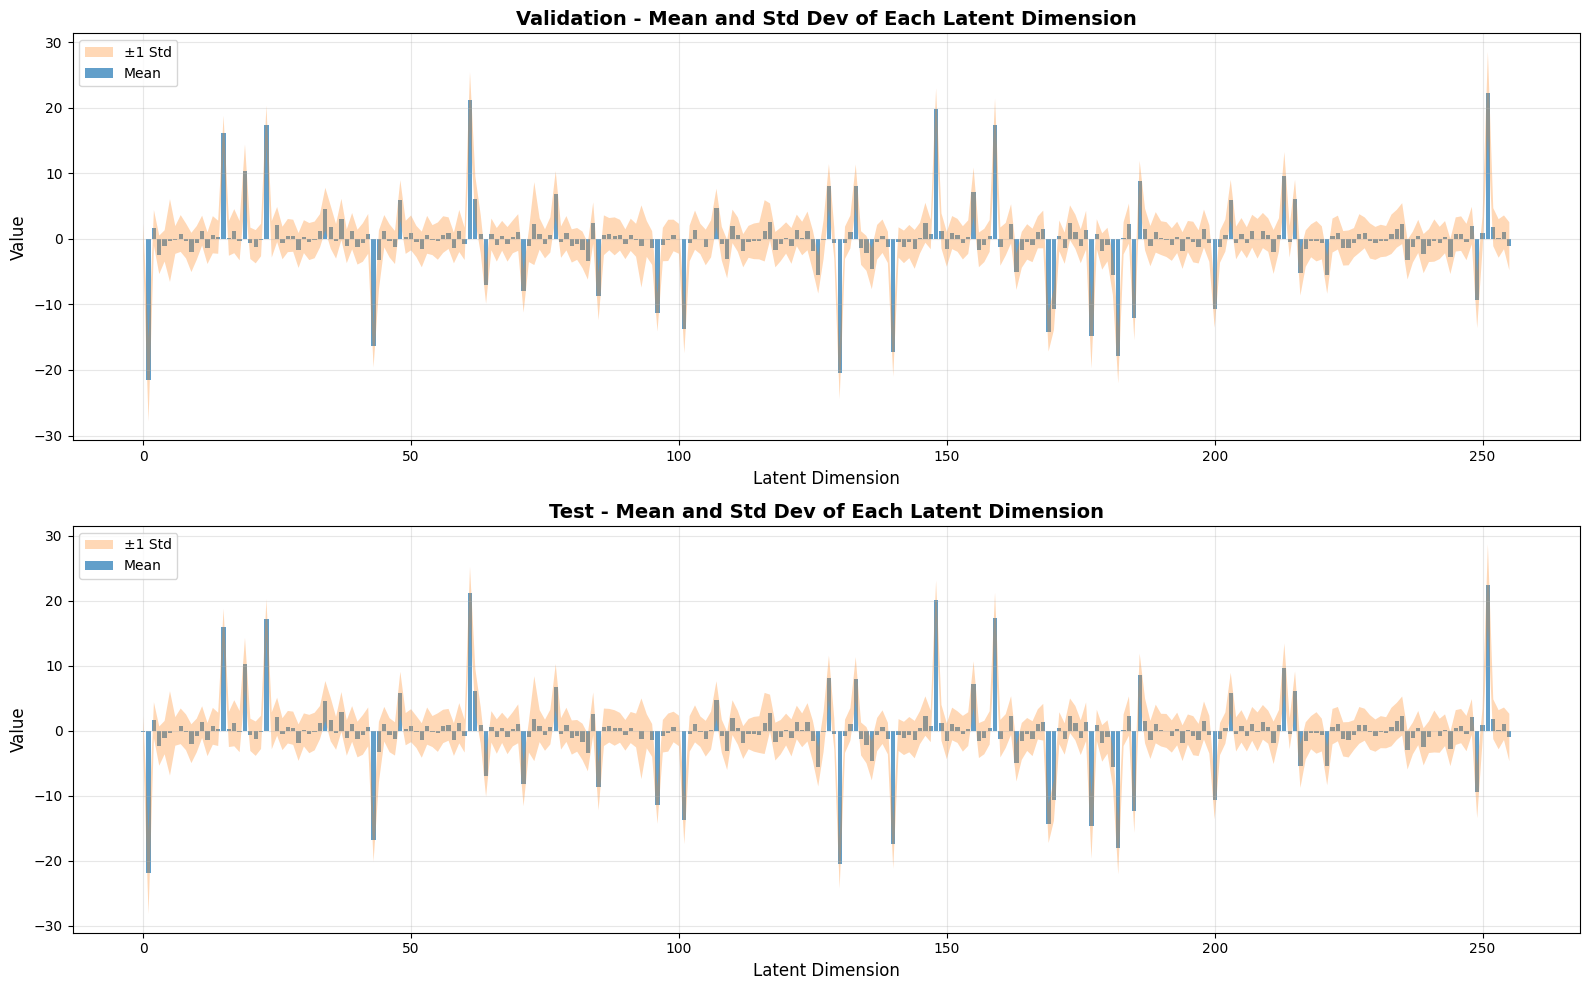

Saved to output/Experiments/LatentVectorAnalysis/latent_dimensions_stats.png


In [13]:
# Plot mean and std of each dimension
fig, axes = plt.subplots(2, 1, figsize=(16, 10))

# Validation
axes[0].bar(val_per_dim_stats['Dimension'], val_per_dim_stats['Mean'], alpha=0.7, label='Mean')
axes[0].fill_between(val_per_dim_stats['Dimension'], 
                       val_per_dim_stats['Mean'] - val_per_dim_stats['Std'],
                       val_per_dim_stats['Mean'] + val_per_dim_stats['Std'],
                       alpha=0.3, label='±1 Std')
axes[0].set_title('Validation - Mean and Std Dev of Each Latent Dimension', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Latent Dimension', fontsize=12)
axes[0].set_ylabel('Value', fontsize=12)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Test
axes[1].bar(test_per_dim_stats['Dimension'], test_per_dim_stats['Mean'], alpha=0.7, label='Mean')
axes[1].fill_between(test_per_dim_stats['Dimension'], 
                       test_per_dim_stats['Mean'] - test_per_dim_stats['Std'],
                       test_per_dim_stats['Mean'] + test_per_dim_stats['Std'],
                       alpha=0.3, label='±1 Std')
axes[1].set_title('Test - Mean and Std Dev of Each Latent Dimension', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Latent Dimension', fontsize=12)
axes[1].set_ylabel('Value', fontsize=12)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(latent_output_dir, 'latent_dimensions_stats.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f"Saved to {os.path.join(latent_output_dir, 'latent_dimensions_stats.png')}")

## PCA Analysis

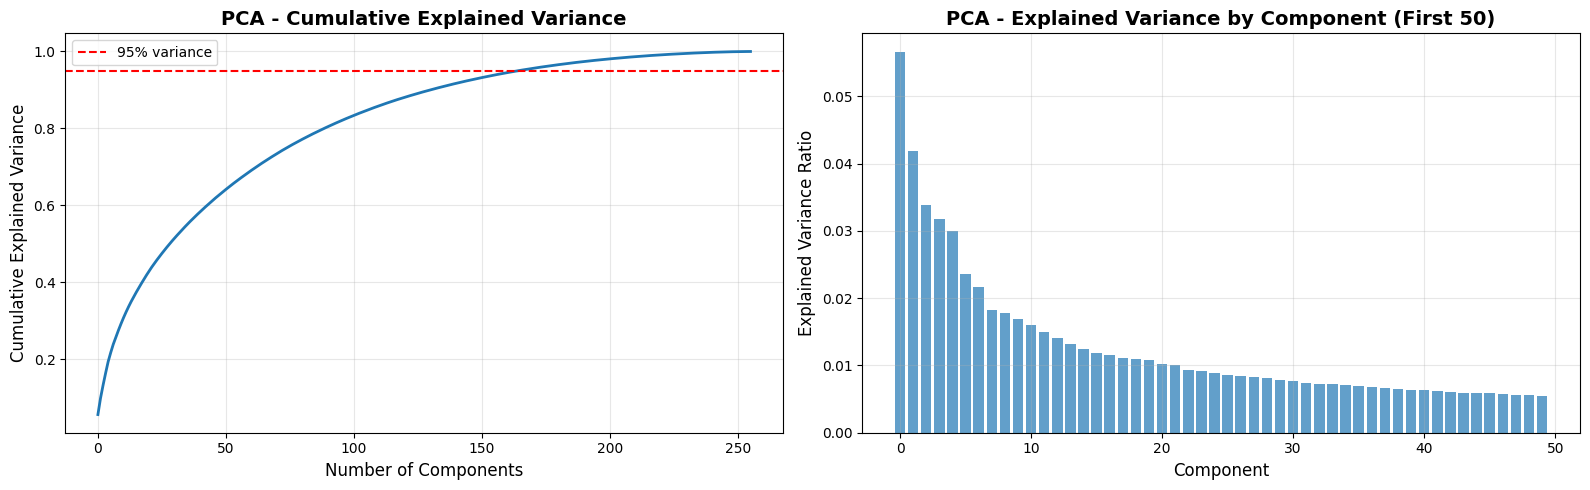

Saved to output/Experiments/LatentVectorAnalysis/pca_explained_variance.png

PCA Summary:
Components needed for 95% variance: 166
Components needed for 99% variance: 219


In [14]:
# Standardize latent vectors
scaler = StandardScaler()
val_latent_scaled = scaler.fit_transform(val_latent_array)
test_latent_scaled = scaler.transform(test_latent_array)

# Apply PCA
pca = PCA()
val_pca = pca.fit_transform(val_latent_scaled)
test_pca = pca.transform(test_latent_scaled)

# Plot explained variance
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Cumulative explained variance
cumsum_var = np.cumsum(pca.explained_variance_ratio_)
axes[0].plot(cumsum_var, linewidth=2)
axes[0].axhline(y=0.95, color='r', linestyle='--', label='95% variance')
axes[0].set_xlabel('Number of Components', fontsize=12)
axes[0].set_ylabel('Cumulative Explained Variance', fontsize=12)
axes[0].set_title('PCA - Cumulative Explained Variance', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)
axes[0].legend()

# Individual explained variance
axes[1].bar(range(min(50, len(pca.explained_variance_ratio_))), 
             pca.explained_variance_ratio_[:50], alpha=0.7)
axes[1].set_xlabel('Component', fontsize=12)
axes[1].set_ylabel('Explained Variance Ratio', fontsize=12)
axes[1].set_title('PCA - Explained Variance by Component (First 50)', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(latent_output_dir, 'pca_explained_variance.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f"Saved to {os.path.join(latent_output_dir, 'pca_explained_variance.png')}")
print(f"\nPCA Summary:")
print(f"Components needed for 95% variance: {np.argmax(cumsum_var >= 0.95) + 1}")
print(f"Components needed for 99% variance: {np.argmax(cumsum_var >= 0.99) + 1}")

## 2D Visualization using PCA

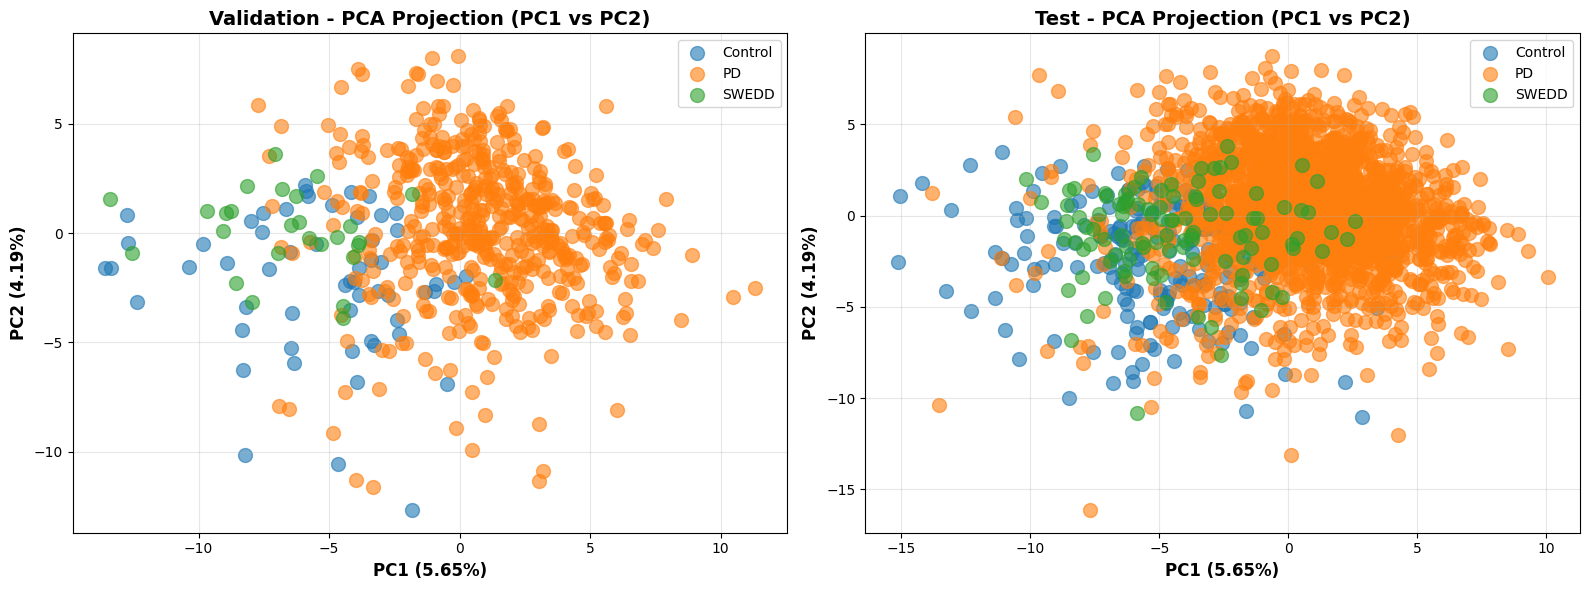

Saved to output/Experiments/LatentVectorAnalysis/pca_2d_projection.png


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Validation
for label in sorted(set(val_labels)):
    mask = np.array(val_labels) == label
    axes[0].scatter(val_pca[mask, 0], val_pca[mask, 1], label=label, s=100, alpha=0.6)

axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%})', fontsize=12, fontweight='bold')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%})', fontsize=12, fontweight='bold')
axes[0].set_title('Validation - PCA Projection (PC1 vs PC2)', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Test
for label in sorted(set(test_labels)):
    mask = np.array(test_labels) == label
    axes[1].scatter(test_pca[mask, 0], test_pca[mask, 1], label=label, s=100, alpha=0.6)

axes[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%})', fontsize=12, fontweight='bold')
axes[1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%})', fontsize=12, fontweight='bold')
axes[1].set_title('Test - PCA Projection (PC1 vs PC2)', fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(latent_output_dir, 'pca_2d_projection.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f"Saved to {os.path.join(latent_output_dir, 'pca_2d_projection.png')}")

## Distribution Histograms

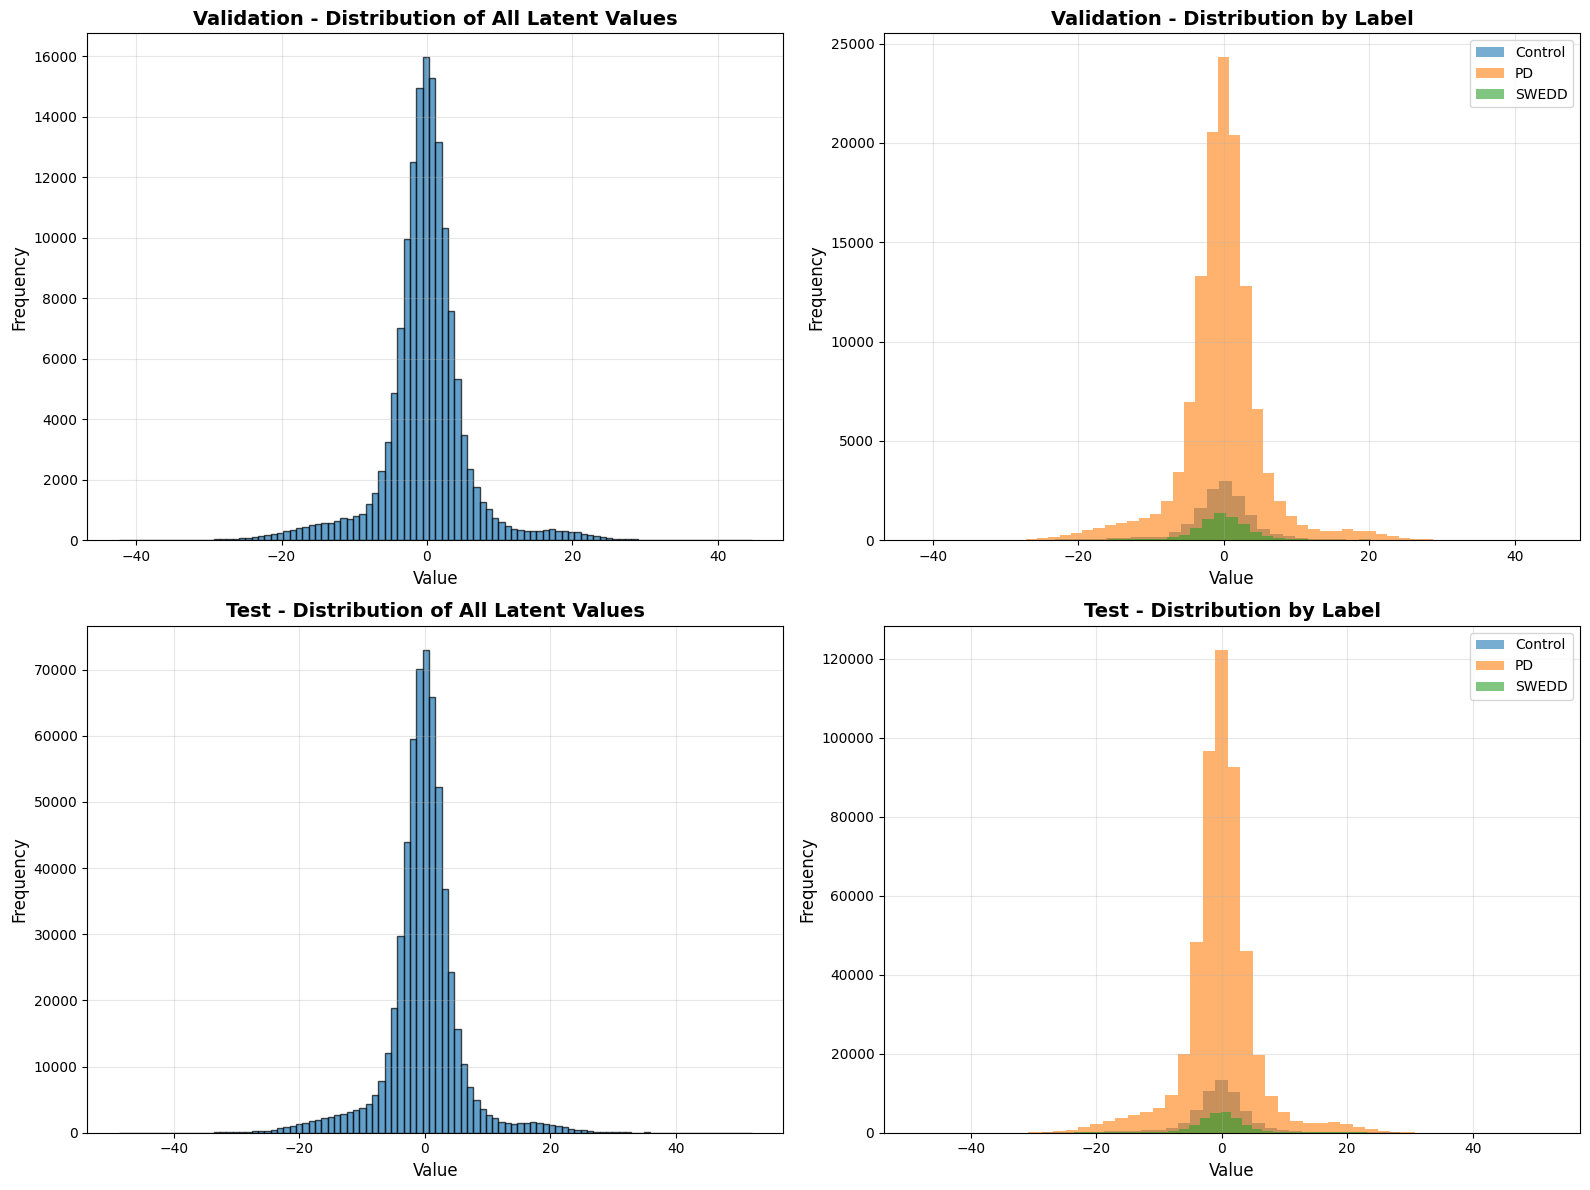

Saved to output/Experiments/LatentVectorAnalysis/latent_distributions.png


In [16]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Validation - all dimensions
axes[0, 0].hist(val_latent_array.flatten(), bins=100, alpha=0.7, edgecolor='black')
axes[0, 0].set_title('Validation - Distribution of All Latent Values', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Value', fontsize=12)
axes[0, 0].set_ylabel('Frequency', fontsize=12)
axes[0, 0].grid(True, alpha=0.3)

# Validation - by label
for label in sorted(set(val_labels)):
    mask = np.array(val_labels) == label
    axes[0, 1].hist(val_latent_array[mask].flatten(), bins=50, alpha=0.6, label=label)

axes[0, 1].set_title('Validation - Distribution by Label', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Value', fontsize=12)
axes[0, 1].set_ylabel('Frequency', fontsize=12)
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Test - all dimensions
axes[1, 0].hist(test_latent_array.flatten(), bins=100, alpha=0.7, edgecolor='black')
axes[1, 0].set_title('Test - Distribution of All Latent Values', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Value', fontsize=12)
axes[1, 0].set_ylabel('Frequency', fontsize=12)
axes[1, 0].grid(True, alpha=0.3)

# Test - by label
for label in sorted(set(test_labels)):
    mask = np.array(test_labels) == label
    axes[1, 1].hist(test_latent_array[mask].flatten(), bins=50, alpha=0.6, label=label)

axes[1, 1].set_title('Test - Distribution by Label', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Value', fontsize=12)
axes[1, 1].set_ylabel('Frequency', fontsize=12)
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(latent_output_dir, 'latent_distributions.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f"Saved to {os.path.join(latent_output_dir, 'latent_distributions.png')}")